In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

all_stocks = []
for name in list(os.listdir('archive')):
    
    path = os.path.join('archive', name)
    single_stock = pd.read_csv(path).set_index('date')
    single_stock = single_stock.loc[:,['close']]
    stock_name = name.split('.')[0]
    single_stock = single_stock.rename(columns={'close':stock_name})
    all_stocks.append(single_stock)

all_stocks = pd.concat(all_stocks, axis=1)
print(all_stocks.info())

<class 'pandas.DataFrame'>
Index: 15555 entries, 2013-01-02 to 1978-03-24
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ABBV    2716 non-null   float64
 1   ABT     10989 non-null  float64
 2   ACN     5596 non-null   float64
 3   AMT     6451 non-null   float64
 4   AXP     13048 non-null  float64
 5   BA      15554 non-null  float64
 6   BABA    2284 non-null   float64
 7   BAC     12775 non-null  float64
 8   BDX     12775 non-null  float64
 9   BHP     10989 non-null  float64
 10  BLK     6049 non-null   float64
 11  BMY     12955 non-null  float64
 12  BP      15554 non-null  float64
 13  BRK     6906 non-null   float64
 14  BUD     3598 non-null   float64
 15  BX      4109 non-null   float64
 16  C       13566 non-null  float64
 17  CAT     15554 non-null  float64
 18  CB      7696 non-null   float64
 19  CI      10474 non-null  float64
 20  COP     10536 non-null  float64
 21  CRM     4863 non-null   float64
 22 

In [3]:
all_stocks = all_stocks.dropna()

print('total shape: ', all_stocks.shape)

unknown = all_stocks[-30:]
stocks = all_stocks[:-30]

print('known shape: ', stocks.shape)
print('unknown shape: ', unknown.shape)


total shape:  (1117, 100)
known shape:  (1087, 100)
unknown shape:  (30, 100)


In [4]:
from sklearn.model_selection import train_test_split

length = stocks.shape[0]

X = []
Y = []
for i in range(0, length - 30, 11):
    x = stocks[i:(i+30)].T.to_numpy()
    y = stocks[i+30:i+31].T.to_numpy()
    y = y.squeeze()
    X.append(x)
    Y.append(y)
    

X = np.concatenate(X)
Y = np.concatenate(Y)

print('total: ', X.shape)


X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.8, shuffle=False)
print('X_train: ', X_train.shape)
print('X_test: ', X_test.shape)


total:  (9700, 30)
X_train:  (7760, 30)
X_test:  (1940, 30)


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from tqdm import tqdm
SEED= 42
np.random.seed(SEED) # We stabilize the seed for reproducability.
models = [
    ('RF', RandomForestRegressor(n_estimators=1000, n_jobs=-1, random_state=SEED)),
    ('DT', DecisionTreeRegressor(random_state=SEED))
]

for m in tqdm(models):
    m[1].fit(X_train, y_train)
    test_pred = m[1].predict(X_test)

    print("%s:\n%0.5f" % (m[0], m[1].score(X_test, y_test)))
    print("test evs: %.5f\n" % explained_variance_score(y_test,test_pred)) # Controlled correction according to the method build

100%|██████████| 2/2 [00:11<00:00,  6.00s/it]

RF:
0.99931
test evs: 0.99931

DT:
0.99867
test evs: 0.99867



In [6]:
unknown_selected = unknown.loc[:,['LLY','PGR','CI','UNH']]
print(unknown_selected.shape)
all_selected = all_stocks.loc[:,['LLY','PGR','CI','UNH']] 
print(all_selected.shape)
print(all_selected[-5:])
print(unknown_selected[:5])

(30, 4)
(1117, 4)
               LLY     PGR      CI     UNH
date                                      
2023-10-10  579.31  142.25  291.76  524.24
2023-10-11  605.28  143.86  294.45  524.13
2023-10-12  610.50  143.30  295.80  525.54
2023-10-13  609.20  154.95  305.09  539.40
2023-10-16  616.64  157.05  312.13  538.03
               LLY     PGR      CI     UNH
date                                      
2023-09-05  558.19  133.52  278.75  480.81
2023-09-06  559.95  134.84  275.63  476.94
2023-09-07  573.23  137.41  281.29  484.81
2023-09-08  586.46  135.76  281.48  480.77
2023-09-11  595.56  137.26  284.82  479.38


In [7]:

y_gt = {    
    'BUD_x' : [],   
    'TM_x' : [],
    'C_x' : [],
    'NOW_x' : []
}

for i in range(len(unknown_selected)):
    x = unknown_selected[i:(i+1)].T.to_numpy()
    for j,k in enumerate(y_gt):
        y_gt[k].append(x[j])

for j,k in enumerate(y_gt):
        y_gt[k] = np.concatenate(y_gt[k])
print(len(y_gt['BUD_x']))   
print(y_gt['BUD_x'][-5:])

30
[579.31 605.28 610.5  609.2  616.64]


In [8]:
sel_x = {       
    'BUD_x' : [],
    'TM_x' : [],
    'C_x' : [],
    'NOW_x' : []
}


for i in range(len(all_selected)-60, len(all_selected)-30):
    x = all_selected[i:(i+30)].T.to_numpy()
    for j,k in enumerate(sel_x):
        sel_x[k].append(x[j])
    

for j,k in enumerate(sel_x):
        sel_x[k] = np.stack(sel_x[k])

print('total: ', len(sel_x['BUD_x']))
print(sel_x['BUD_x'][-5:])


total:  30
[[553.92 553.9  547.99 554.2  557.11 558.19 559.95 573.23 586.46 595.56
  599.3  598.88 591.61 575.66 571.28 574.96 569.64 550.13 550.54 552.29
  550.01 549.76 544.45 537.13 538.29 525.19 531.46 541.48 565.22 571.76]
 [553.9  547.99 554.2  557.11 558.19 559.95 573.23 586.46 595.56 599.3
  598.88 591.61 575.66 571.28 574.96 569.64 550.13 550.54 552.29 550.01
  549.76 544.45 537.13 538.29 525.19 531.46 541.48 565.22 571.76 579.31]
 [547.99 554.2  557.11 558.19 559.95 573.23 586.46 595.56 599.3  598.88
  591.61 575.66 571.28 574.96 569.64 550.13 550.54 552.29 550.01 549.76
  544.45 537.13 538.29 525.19 531.46 541.48 565.22 571.76 579.31 605.28]
 [554.2  557.11 558.19 559.95 573.23 586.46 595.56 599.3  598.88 591.61
  575.66 571.28 574.96 569.64 550.13 550.54 552.29 550.01 549.76 544.45
  537.13 538.29 525.19 531.46 541.48 565.22 571.76 579.31 605.28 610.5 ]
 [557.11 558.19 559.95 573.23 586.46 595.56 599.3  598.88 591.61 575.66
  571.28 574.96 569.64 550.13 550.54 552.29 550.01

In [9]:
RF_pred = {
    'BUD_x' : [],
    'TM_x' : [],
    'C_x' : [],
    'NOW_x' : []
}

DT_pred = {
    'BUD_x' : [],
    'TM_x' : [],
    'C_x' : [],
    'NOW_x' : []
}

for j in sel_x:
    RF_pred[j] = models[0][1].predict(sel_x[j])
    DT_pred[j] = models[1][1].predict(sel_x[j]) 
    print(j, "RF evs: %.5f\n" % explained_variance_score(RF_pred[j], y_gt[j]))
    print(j, "DT evs: %.5f\n" % explained_variance_score(DT_pred[j], y_gt[j]))


print('total: ', len(RF_pred['BUD_x']))
print(RF_pred['BUD_x'][-5:])


BUD_x RF evs: 0.74648

BUD_x DT evs: 0.66263

TM_x RF evs: 0.48105

TM_x DT evs: 0.48284

C_x RF evs: 0.66549

C_x DT evs: 0.40131

NOW_x RF evs: 0.90638

NOW_x DT evs: 0.90022

total:  30
[575.62328 575.26716 595.2571  603.43645 607.76799]


In [10]:
shifted_y_gt = {
    'BUD_x' : [],   
    'TM_x' : [],
    'C_x' : [],
    'NOW_x' : []
}

RF_single_returns = {
    'BUD_x' : [],   
    'TM_x' : [],
    'C_x' : [],
    'NOW_x' : []
}

DT_single_returns = {
    'BUD_x' : [],   
    'TM_x' : [],
    'C_x' : [],
    'NOW_x' : []
}

for index, stock in enumerate(y_gt):
    shifted_y_gt[stock] = np.concatenate((all_selected[-31:-30].T.to_numpy()[index], y_gt[stock][:-1]))
    RF_single_returns[stock] = np.log(RF_pred[stock] / shifted_y_gt[stock])
    DT_single_returns[stock] = np.log(DT_pred[stock] / shifted_y_gt[stock])

# print(shifted_y_gt['BUD_x'])
print(RF_single_returns['BUD_x'])

[-0.00881074 -0.00363171 -0.00702508 -0.00100188 -0.01536006 -0.00478592
 -0.00684424 -0.00567987  0.00399359  0.00844847  0.01464335  0.0060678
  0.01302952  0.00726416 -0.00423559 -0.00568294 -0.00162815 -0.00239124
 -0.00173533 -0.00867107 -0.00872728 -0.00119533 -0.0092564   0.00109848
 -0.00794487  0.0067341  -0.00700318 -0.01669775 -0.01163756 -0.00235341]


In [11]:
returns = np.log(all_selected[:-30] / all_selected[:-30].shift(1))   # 收益
print(returns.shape)

print (32*"-")
print ("协方差")
cov = returns.cov()
print (cov)
print (32*"-")
print("方差")
std = np.sqrt(returns.var())
print(std)
print (32*"-")

(1087, 4)
--------------------------------
协方差
          LLY       PGR        CI       UNH
LLY  0.000392  0.000127  0.000166  0.000172
PGR  0.000127  0.000326  0.000153  0.000145
CI   0.000166  0.000153  0.000482  0.000325
UNH  0.000172  0.000145  0.000325  0.000368
--------------------------------
方差
LLY    0.019793
PGR    0.018044
CI     0.021953
UNH    0.019191
dtype: float64
--------------------------------


In [12]:
from tqdm import tqdm, tgrange

def gen_weights(n):
    weights = np.random.rand(n)
    return weights / np.sum(weights)

def port_ret(w, r, day):
    ret = 0.
    for i, stock in enumerate(y_gt):
        ret += r[stock][day] * w[i]
    return ret

def port_std(w):
    return np.sqrt(np.dot(w.T, np.dot(returns.cov(), w)))


def gen_ports(times, r, day):
    for _ in range(times):
        w = gen_weights(4)
        yield (port_std(w), port_ret(w, r, day), w)


In [13]:
np.random.seed(SEED)
RF_port_ret = []
DT_port_ret = []
real_return = np.log(all_selected / all_selected.shift(1))[-30:].to_numpy()


for day in tqdm(range(30), desc='RF', unit='day'):
    df = pd.DataFrame(gen_ports(5000, RF_single_returns, 1), columns=['std', 'ret', 'w'])
    df['sharpe'] = (df['ret'] - 5.45/2520) / df['std']
    best_weight = df.loc[df.sharpe.idxmax()].w
    RF_port_ret.append(np.sum(real_return[day] * best_weight)) 

for day in tqdm(range(30), desc='DT', unit='day'):
    df = pd.DataFrame(gen_ports(5000, DT_single_returns, 1), columns=['std', 'ret', 'w'])
    df['sharpe'] = (df['ret'] - 5.45/252) / df['std']
    best_weight = df.loc[df.sharpe.idxmax()].w
    DT_port_ret.append(np.sum(real_return[day] * best_weight))

print(RF_port_ret)   
print(len(DT_port_ret))

DT: 100%|██████████| 30/30 [00:13<00:00,  2.21day/s]

[np.float64(-0.013647463271012133), np.float64(0.008264606420176616), np.float64(0.01868431616371831), np.float64(-0.01067912451357515), np.float64(0.009848362017543718), np.float64(0.009502352501038576), np.float64(0.0025832062646714248), np.float64(0.0020601407027820416), np.float64(-0.00600431477774427), np.float64(0.010847765291660049), np.float64(0.009480098184560333), np.float64(0.0038156714798130206), np.float64(-0.00048340478352946266), np.float64(0.00570611632346803), np.float64(-0.004413552153331344), np.float64(-0.012064132015418998), np.float64(-0.0010645706228067193), np.float64(-0.0002845016004997358), np.float64(-0.008926425666465843), np.float64(-0.0013287877408439627), np.float64(0.0014348315203439202), np.float64(0.018878431093450117), np.float64(0.0030490904509312966), np.float64(0.006910665751440155), np.float64(0.0028961939493641607), np.float64(-0.004681951022909474), np.float64(0.011159481380727998), np.float64(-0.002864025378753605), np.float64(0.071793064993906

In [14]:
def cal_cum_prof(ret):
    data = pd.DataFrame(ret, columns=['day_ret'])
    data['cum_profit'] = pd.DataFrame(1+data['day_ret']).cumprod()-1
    return data['cum_profit'][-1:].to_list()[0]

In [15]:
nasdaq = pd.read_csv('nasdaq31.csv').set_index('Date')["Close"]
nasdaq = np.log(nasdaq / nasdaq.shift(1))[1:]
nasdaq = nasdaq.to_list()

nasdaq_cul_ret = cal_cum_prof(nasdaq)

RF_cul_ret = cal_cum_prof(RF_port_ret)
DT_cul_ret = cal_cum_prof(DT_port_ret)

print('nasdaq 收益率：', nasdaq_cul_ret)
print('RF 收益率：', RF_cul_ret)
print('DT 收益率：', DT_cul_ret)

nasdaq 收益率： -0.034484709805679414
RF 收益率： 0.14921754674520749
DT 收益率： 0.10396724326624907


<Axes: title={'center': 'LSTM'}, xlabel='Day', ylabel='return rate'>

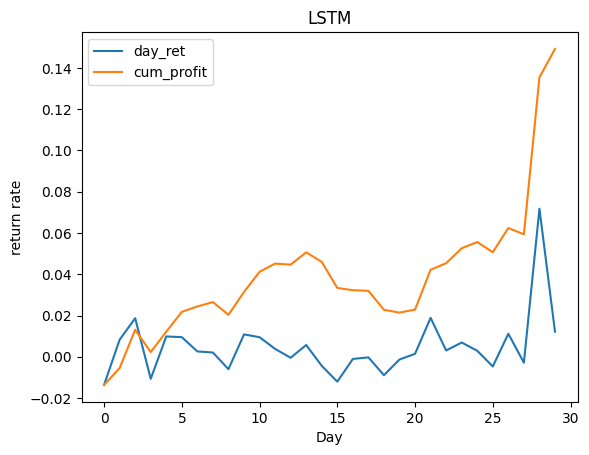

In [16]:
fff = pd.DataFrame(RF_port_ret, columns=['day_ret'])
fff['cum_profit'] = pd.DataFrame(1+fff['day_ret']).cumprod()-1
fff.plot(title='LSTM', xlabel='Day', ylabel='return rate')

<Axes: title={'center': 'Random Forest'}, xlabel='Day', ylabel='return rate'>

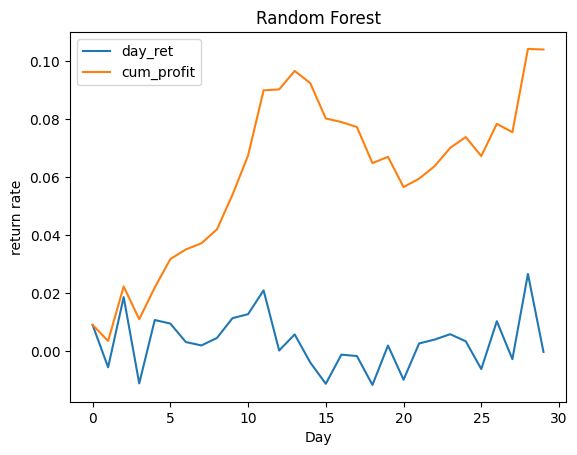

In [17]:
ggg = pd.DataFrame(DT_port_ret, columns=['day_ret'])
ggg['cum_profit'] = pd.DataFrame(1+ggg['day_ret']).cumprod()-1
ggg.plot(title='Random Forest', xlabel='Day', ylabel='return rate')

<Axes: xlabel='Date', ylabel='return rate'>

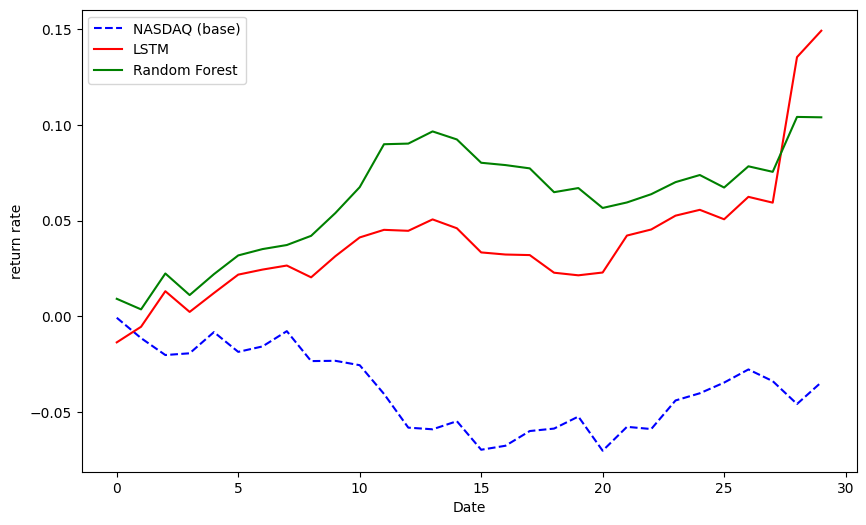

In [18]:
nar = pd.DataFrame(nasdaq, columns=['day_ret'])
nar['cum_profit'] = pd.DataFrame(1+nar['day_ret']).cumprod()-1

nar['cum_profit'].plot(color='b', figsize=(10, 6), legend=True, label='NASDAQ (base)', linestyle="dashed")
fff['cum_profit'].plot(color='r',legend=True, label='LSTM', xlabel='Date')
ggg['cum_profit'].plot(color='g', legend=True, label='Random Forest',ylabel='return rate')

In [19]:
na.plot( figsize=(10, 6))

NameError: name 'na' is not defined